In [1]:
import sys
sys.path.insert(0, '/home/xp/stereo_toolbox/')

import os
os.environ['HTTP_PROXY'] = 'http://10.13.73.98:7890'
os.environ['HTTPS_PROXY'] = 'http://10.13.73.98:7890'

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
torch.backends.cudnn.benchmark = True
import matplotlib.pyplot as plt
import argparse

import warnings
warnings.filterwarnings("ignore")

from stereo_toolbox.datasets import *
from stereo_toolbox.models import *
from stereo_toolbox.evaluation import *
from stereo_toolbox.loss_functions import *


device = 'cuda:0'
model = load_checkpoint_flexible(IGEVStereo(),
                                 '/home/xp/stereo_toolbox/stereo_toolbox/models/IGEVStereo/sceneflow.pth',
                                 )
model = nn.DataParallel(model).to(device)

Created a temporary directory at /tmp/tmpmafjhltq
Writing /tmp/tmpmafjhltq/_remote_module_non_scriptable.py


  0%|          | 0/612510 [00:00<?, ?it/s]

tensor([0])
tensor([[[[0.1928]]]], device='cuda:0')


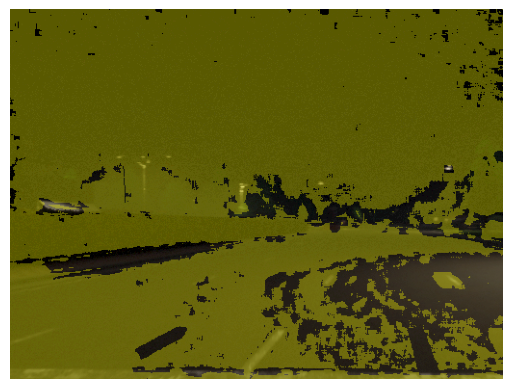

tensor([[[[0.1928]]]], device='cuda:0')


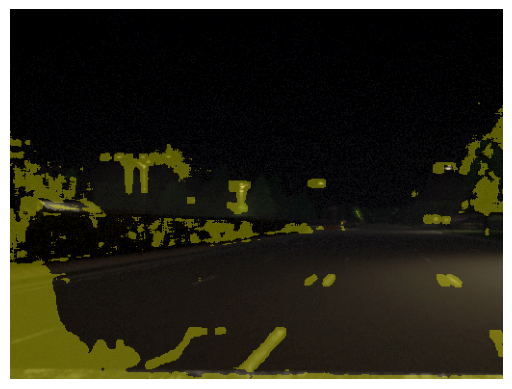

tensor([[[[0.1928]]]], device='cuda:0')


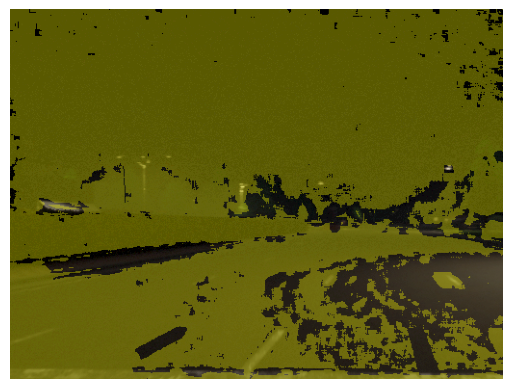

tensor([[[[0.1928]]]], device='cuda:0')


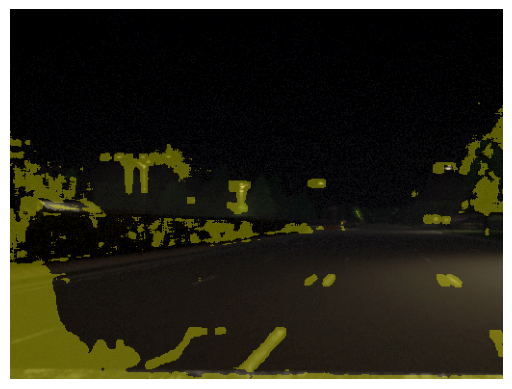

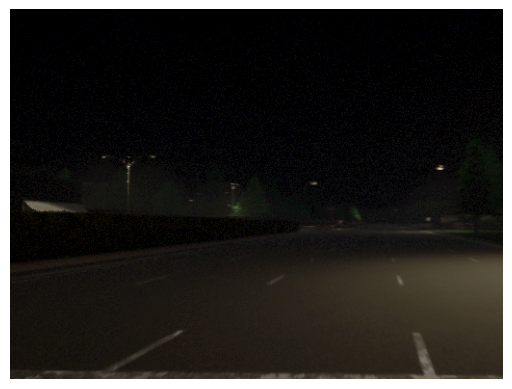

  0%|          | 0/612510 [00:01<?, ?it/s]

AssertionError: 

: 

In [ ]:
sys.path.insert(0, '/home/xp/BaCon/')
from dataloader import BaCon_Dataset

dataset = BaCon_Dataset(split='bacon', training=True, root_dir='/data1/xp/Carla/data6/')
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

for i, data in enumerate(tqdm(dataloader)):
    left = data['left_student'].to(device)
    right = data['right_student'].to(device)
    # gt_disp = data['gt_disp'].to(device).unsqueeze(1)
    raw_left = data['raw_left_student'].to(device)
    raw_right = data['raw_right_student'].to(device)
    _, pred = model(left, right)
    pred = pred[-1]

    print(data['student_flip_flag'])

    # assert pred.shape == gt_disp.shape, f"Predicted shape {pred.shape} does not match ground truth shape {gt_disp.shape}"

    raw_left_np = raw_left.squeeze().permute(1,2,0).cpu().numpy()
    raw_right_np = raw_right.squeeze().permute(1,2,0).cpu().numpy()

    for occlusion_threshold in [0.2, 1.0]:
        for stationary in [True, False]:
            occ_mask = auto_mask(raw_left, raw_right, pred, stationary=stationary, occlusion=True, occlusion_threshold=occlusion_threshold)
            occ_mask = occ_mask.squeeze().cpu().numpy()[..., np.newaxis]
            masked_raw_left = raw_left_np * (occ_mask) + raw_left_np * (1-occ_mask) * 0.65 + (1-occ_mask) * [1.0, 1.0, 0] * 0.35
            # 给 occ_mask 设置透明度 并叠加到 raw_left 上
            plt.imshow(masked_raw_left, alpha=1.0)
            plt.axis('off')
            plt.show()
    plt.imshow(raw_right_np)
    plt.axis('off')
    plt.show()


    print()

    assert 0